# 06 — Results Analysis  *(augmented_lags — clean rebuild)*

Loads all outputs from `05_Model_Training_augmented_lags` and produces dissertation figures.

Input:  `data/processed/augmented_lags/`
Output: `figures/augmented_lags/` (additional dissertation figures)


## Cell 1 — Imports and Load All Outputs

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.utils import resample
import shap

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
AUG_DIR = BASE / 'data' / 'processed' / 'augmented_lags'
FIG_DIR = BASE / 'figures' / 'augmented_lags'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load all outputs from notebook 05
df_model   = pd.read_csv(AUG_DIR / 'df_model_aug.csv')
results_df = pd.read_csv(AUG_DIR / 'model_results.csv')
shap_df    = pd.read_csv(AUG_DIR / 'shap_values_m3.csv')
oos_df     = pd.read_csv(AUG_DIR / 'oos_predictions.csv')
M1_FEATURES = pd.read_csv(AUG_DIR / 'M1_features.csv', header=None)[0].tolist()
M2_FEATURES = pd.read_csv(AUG_DIR / 'M2_features.csv', header=None)[0].tolist()
M3_FEATURES = pd.read_csv(AUG_DIR / 'M3_features.csv', header=None)[0].tolist()

# Target column — whatever crisis column is in the dataset
TARGET = next(c for c in oos_df.columns if 'crisis' in c.lower()
              and c not in ['crisisjst','crisisjst_old'])
print(f'Target column   : {TARGET}')
print(f'df_model shape  : {df_model.shape}')
print(f'SHAP values     : {shap_df.shape}')
print(f'OOS predictions : {oos_df.shape}')
print(f'OOS columns     : {oos_df.columns.tolist()}')
print()
print('Results summary:')
print(results_df.to_string(index=False))

Target column   : crisis_w2
df_model shape  : (372, 158)
SHAP values     : (372, 46)
OOS predictions : (372, 6)
OOS columns     : ['year', 'iso', 'crisis_w2', 'prob_m1', 'prob_m2', 'prob_m3']

Results summary:
                       Model    AUROC    AUPRC    Brier
      M1_Logistic_macro_lag1 0.924302 0.566306 0.234471
M2_RandomForest_macro_lag123 0.968150 0.750263 0.056657
       M3_XGBoost_sent_lag12 0.956588 0.680510 0.074221


## Cell 2 — Metrics Summary with Bootstrap Confidence Intervals

In [3]:
def bootstrap_auroc(y_true, y_prob, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    scores = []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if y_true[idx].sum() == 0:
            continue
        scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(scores, [2.5, 97.5])

# Build y_true and y_prob vectors from oos_df
# The target column is crisis_w2 — same for all three models
y_true = oos_df[TARGET].values

model_probs = {
    'M1_Logistic_macro_lag1':       oos_df['prob_m1'].values,
    'M2_RandomForest_macro_lag123': oos_df['prob_m2'].values,
    'M3_XGBoost_sent_lag12':        oos_df['prob_m3'].values,
}

base_rate = y_true.mean()
print('=' * 76)
print(f' {"Model":<38} {"AUROC":>7} {"95% CI":>14} {"AUPRC":>7} {"Brier":>7}')
print('-' * 76)

metrics_records = []
for name, yp in model_probs.items():
    mask = ~np.isnan(yp)
    yt, yp_clean = y_true[mask], yp[mask]
    if yt.sum() == 0:
        continue
    auroc = roc_auc_score(yt, yp_clean)
    auprc = average_precision_score(yt, yp_clean)
    brier = brier_score_loss(yt, yp_clean)
    ci_lo, ci_hi = bootstrap_auroc(yt, yp_clean)
    print(f' {name:<38} {auroc:>7.4f} [{ci_lo:.3f},{ci_hi:.3f}] {auprc:>7.4f} {brier:>7.4f}')
    metrics_records.append({'Model': name, 'AUROC': auroc, 'CI_lo': ci_lo,
                            'CI_hi': ci_hi, 'AUPRC': auprc, 'Brier': brier})

print('=' * 76)
print(f' Baseline AUPRC (no-skill): {base_rate:.4f}')
print(f' Crisis events: {int(y_true.sum())} ({TARGET})')

metrics_df = pd.DataFrame(metrics_records)
metrics_df.to_csv(AUG_DIR / 'metrics_with_ci.csv', index=False)
print(f'\nSaved → {AUG_DIR}/metrics_with_ci.csv')

 Model                                    AUROC         95% CI   AUPRC   Brier
----------------------------------------------------------------------------
 M1_Logistic_macro_lag1                  0.9243 [0.880,0.963]  0.5663  0.2345
 M2_RandomForest_macro_lag123            0.9682 [0.944,0.987]  0.7503  0.0567
 M3_XGBoost_sent_lag12                   0.9566 [0.929,0.979]  0.6805  0.0742
 Baseline AUPRC (no-skill): 0.1048
 Crisis events: 39 (crisis_w2)

Saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_lags/metrics_with_ci.csv


## Cell 3 — SHAP Importance by Lag Depth

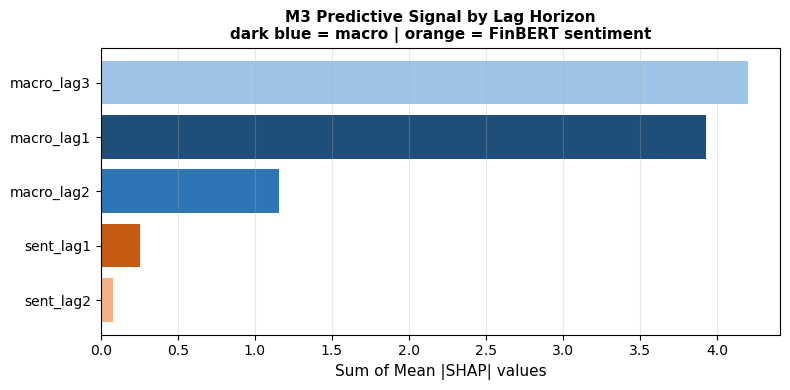

Lag group importance:
macro_lag3    4.197361
macro_lag1    3.929704
macro_lag2    1.153973
sent_lag1     0.257590
sent_lag2     0.080605

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_lags/fig_shap_lag_depth.png


In [5]:
shap_values = shap_df.values
mean_abs    = pd.Series(np.abs(shap_values).mean(axis=0), index=M3_FEATURES)

# Classify each feature into its lag group
def get_lag_group(feat):
    sent_keys = ['P_pos','P_neg','P_neutral','net_sentiment']
    is_sent = any(s in feat for s in sent_keys)
    if '_lag1' in feat and is_sent: return 'sent_lag1'
    if '_lag2' in feat and is_sent: return 'sent_lag2'
    if '_lag1' in feat: return 'macro_lag1'
    if '_lag2' in feat: return 'macro_lag2'
    if '_lag3' in feat: return 'macro_lag3'
    return 'other'

groups   = pd.Series({f: get_lag_group(f) for f in M3_FEATURES})
lag_imp  = mean_abs.groupby(groups).sum().reindex(
    ['macro_lag1','macro_lag2','macro_lag3','sent_lag1','sent_lag2','other']
).dropna().sort_values(ascending=False)

palette  = {'macro_lag1':'#1F4E79','macro_lag2':'#2E75B6','macro_lag3':'#9DC3E6',
            'sent_lag1':'#C55A11','sent_lag2':'#F4B183','other':'#AAAAAA'}

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(lag_imp.index[::-1], lag_imp.values[::-1],
        color=[palette.get(g,'#999') for g in lag_imp.index[::-1]])
ax.set_xlabel('Sum of Mean |SHAP| values', fontsize=11)
ax.set_title('M3 Predictive Signal by Lag Horizon\n'
             'dark blue = macro | orange = FinBERT sentiment',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_shap_lag_depth.png', dpi=150, bbox_inches='tight')
plt.show()

print('Lag group importance:')
print(lag_imp.to_string())
print(f'\nSaved → {FIG_DIR}/fig_shap_lag_depth.png')

## Cell 4 — Top-20 Feature Importance (SHAP bar chart)

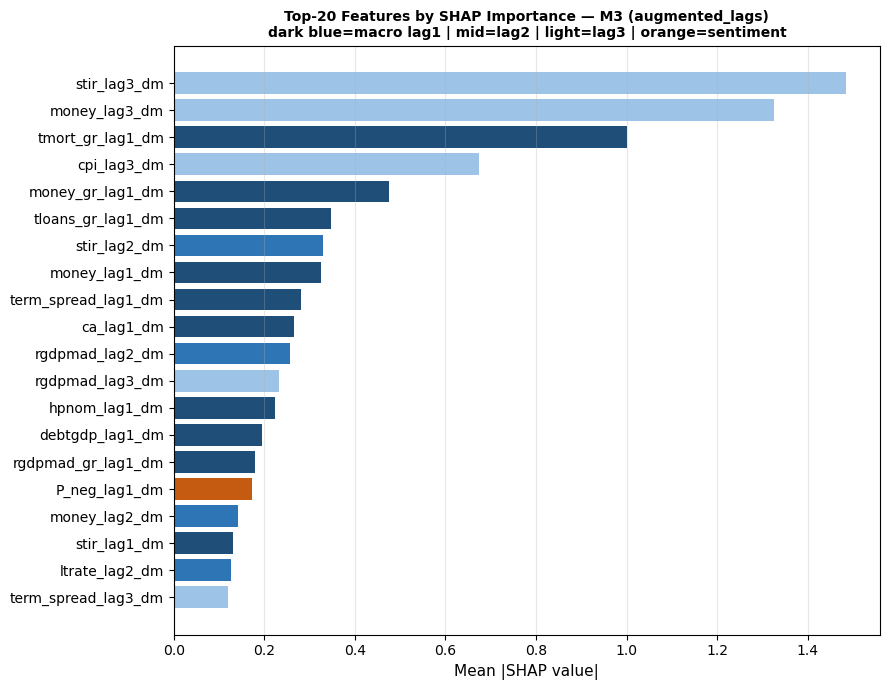

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_lags/fig_shap_top20.png


In [7]:
mean_abs_sorted = mean_abs.sort_values(ascending=True).tail(20)

def feat_color(f):
    sent_keys = ['P_pos','P_neg','P_neutral','net_sentiment']
    if any(s in f for s in sent_keys): return '#C55A11'
    if '_lag3' in f: return '#9DC3E6'
    if '_lag2' in f: return '#2E75B6'
    return '#1F4E79'

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(mean_abs_sorted.index, mean_abs_sorted.values,
        color=[feat_color(f) for f in mean_abs_sorted.index])
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Top-20 Features by SHAP Importance — M3 (augmented_lags)\n'
             'dark blue=macro lag1 | mid=lag2 | light=lag3 | orange=sentiment',
             fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_shap_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/fig_shap_top20.png')

## Cell 5 — Temporal Crisis Probability Analysis

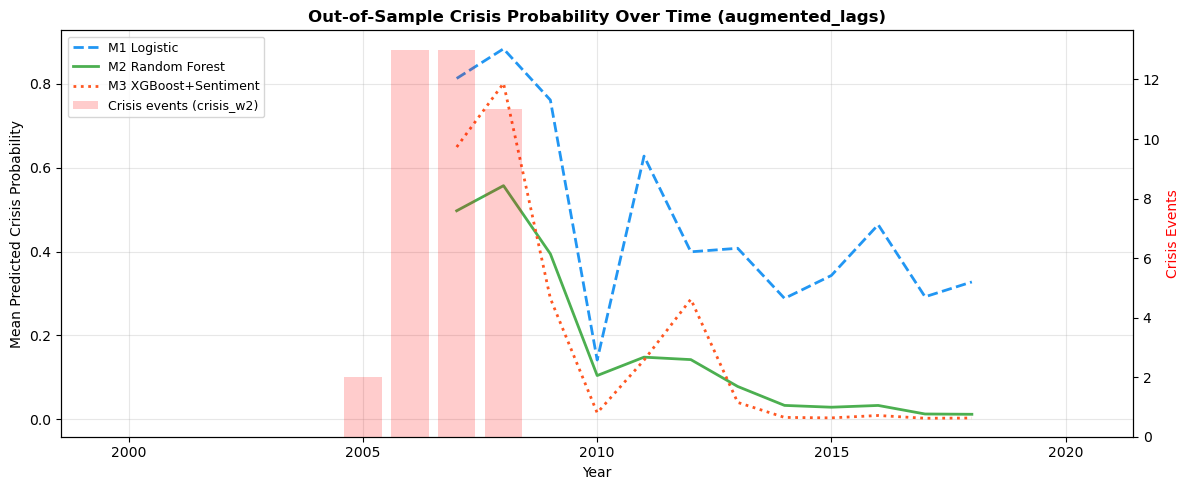

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_lags/fig_temporal_probs.png


In [9]:
yearly = oos_df.groupby('year').agg(
    prob_m1=('prob_m1','mean'),
    prob_m2=('prob_m2','mean'),
    prob_m3=('prob_m3','mean'),
    actual_crises=(TARGET,'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(yearly['year'], yearly['prob_m1'], color='#2196F3', lw=2,
         label='M1 Logistic', linestyle='--')
ax1.plot(yearly['year'], yearly['prob_m2'], color='#4CAF50', lw=2,
         label='M2 Random Forest')
ax1.plot(yearly['year'], yearly['prob_m3'], color='#FF5722', lw=2,
         label='M3 XGBoost+Sentiment', linestyle=':')
ax2.bar(yearly['year'], yearly['actual_crises'], alpha=0.2,
        color='red', label='Crisis events (crisis_w2)')

ax1.set_xlabel('Year')
ax1.set_ylabel('Mean Predicted Crisis Probability')
ax2.set_ylabel('Crisis Events', color='red')
ax1.set_title('Out-of-Sample Crisis Probability Over Time (augmented_lags)',
              fontsize=12, fontweight='bold')

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_temporal_probs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/fig_temporal_probs.png')

## Cell 6 — SHAP Beeswarm (reload from CSV)

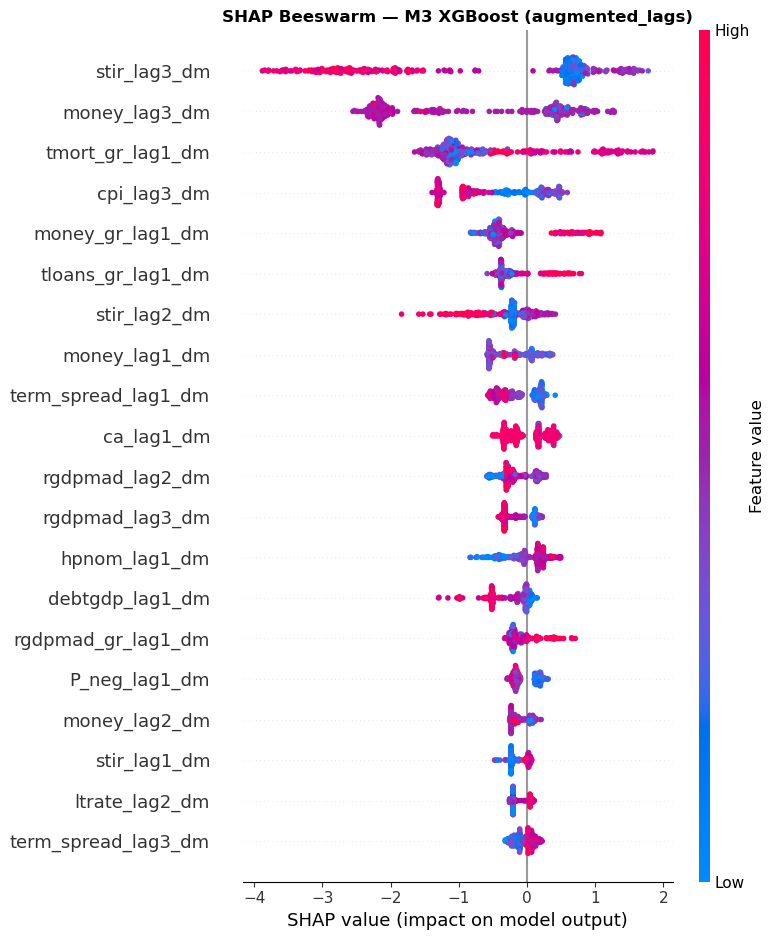

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_lags/fig_shap_beeswarm.png


In [11]:
import xgboost as xgb, tempfile, os

X_m3  = df_model[M3_FEATURES]
y_all = df_model[TARGET]
scale_pw = (y_all == 0).sum() / (y_all == 1).sum()

xgb_full = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pw, random_state=42,
    eval_metric='logloss', verbosity=0)
xgb_full.fit(X_m3, y_all)

tmp = tempfile.mktemp(suffix='.json')
xgb_full.save_model(tmp); xgb_full.load_model(tmp); os.remove(tmp)

explainer   = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X_m3)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_m3, feature_names=M3_FEATURES,
                  show=False, plot_type='dot')
plt.title('SHAP Beeswarm — M3 XGBoost (augmented_lags)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/fig_shap_beeswarm.png')

## Cell 7 — Final Output Inventory

In [13]:
print('=' * 65)
print(' NOTEBOOK 06 augmented_lags COMPLETE')
print('=' * 65)
print()
print(f'Target used : {TARGET}')
print(f'Crisis events in OOS: {int(y_true.sum())}')
print()
print('Figures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name:45s}  {f.stat().st_size//1024:4d} KB')
print()
print('Data files:')
for f in sorted(AUG_DIR.glob('*.csv')):
    print(f'  {f.name:45s}  {f.stat().st_size//1024:4d} KB')

 NOTEBOOK 06 augmented_lags COMPLETE

Target used : crisis_w2
Crisis events in OOS: 39

Figures:
  fig_shap_beeswarm.png                           235 KB
  fig_shap_lag_depth.png                           39 KB
  fig_shap_top20.png                              100 KB
  fig_temporal_probs.png                          103 KB
  roc_pr_curves.png                               113 KB
  shap_by_lag_depth.png                            38 KB
  shap_fold_stability.png                          78 KB
  shap_summary_m3.png                             235 KB

Data files:
  df_model_aug.csv                                840 KB
  M1_features.csv                                   0 KB
  M2_features.csv                                   0 KB
  M3_features.csv                                   0 KB
  metrics_with_ci.csv                               0 KB
  model_results.csv                                 0 KB
  oos_predictions.csv                              17 KB
  shap_values_m3.csv               